# NewsBot 2.0 — Section 1: Project Setup

**Michelle Adu-Asah**  
**NLP ITAI-2373 — Final Project**

This project is an upgraded version of my midterm NewsBot where I originally focused on classifying news articles and analyzing text patterns.  
For the final, I expanded it into a more complete system that can not only classify news, but also analyze sentiment, find main topics, generate summaries, and detect the language of the article.  

The goal is to build a simple but functional NLP system that takes in a news article and returns useful insights all in one place, showing how different techniques from the course can work together in a real workflow.

## Install

In [16]:
!pip install sumy langdetect deep-translator

## Import Libraries

In [17]:
import re
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

warnings.filterwarnings('ignore')

import nltk
import spacy
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.metrics.pairwise import cosine_similarity

from sumy.parsers.plaintext import PlaintextParser
from sumy.nlp.tokenizers import Tokenizer
from sumy.summarizers.lsa import LsaSummarizer

from langdetect import detect
from deep_translator import MyMemoryTranslator

for pkg in ['stopwords', 'wordnet', 'punkt_tab', 'vader_lexicon']:
    nltk.download(pkg, quiet=True)

print('Imports ready')

Imports ready


## Config

In [18]:
class Config:
    DATA_PATH = 'BBC News Train.csv'
    TFIDF_FEATURES = 1000
    POS_THRESHOLD = 0.05
    NEG_THRESHOLD = -0.05
    N_TOPICS = 5
    SUMMARY_SENTENCES = 3

config = Config()

In [19]:
df = pd.read_csv(config.DATA_PATH)
df = df.rename(columns={'Text': 'content', 'Category': 'category'})

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = [lemmatizer.lemmatize(w) for w in text.split() if w not in stop_words]
    return ' '.join(words)

df['cleaned'] = df['content'].apply(clean_text)

print("Data ready:", len(df))

Data ready: 1490


In [20]:
display(df.head())

,ArticleId,content,category,cleaned
0,1833,worldcom ex-boss launches defence lawyers defe...,business,worldcom exboss launch defence lawyer defendin...
1,154,german business confidence slides german busin...,business,german business confidence slide german busine...
2,1101,bbc poll indicates economic gloom citizens in ...,business,bbc poll indicates economic gloom citizen majo...
3,1976,lifestyle governs mobile choice faster bett...,tech,lifestyle governs mobile choice faster better ...
4,917,enron bosses in $168m payout eighteen former e...,business,enron boss payout eighteen former enron direct...


## Load and clean data

In [21]:
df = pd.read_csv(config.DATA_PATH)
df = df.rename(columns={'Text': 'content', 'Category': 'category'})

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = [lemmatizer.lemmatize(w) for w in text.split() if w not in stop_words]
    return ' '.join(words)

df['cleaned'] = df['content'].apply(clean_text)

print("Data ready:", len(df))

Data ready: 1490


## System

In [22]:
class NewsBot:
    def __init__(self):
        self.classifier = None
        self.sentiment = None
        self.topic = None
        self.summarizer = None

    def analyze(self, text):
        return {
            "category": self.classifier.predict(text),
            "sentiment": self.sentiment.analyze(text),
            "topics": self.topic.get_topics(text),
            "summary": self.summarizer.summarize(text),
            "language": detect(text)
        }

newsbot = NewsBot()

## Sentiment

In [23]:
class Sentiment:
    def __init__(self):
        self.analyzer = SentimentIntensityAnalyzer()

    def analyze(self, text):
        score = self.analyzer.polarity_scores(text)['compound']
        if score > 0.05:
            label = "positive"
        elif score < -0.05:
            label = "negative"
        else:
            label = "neutral"
        return {"label": label, "score": score}

newsbot.sentiment = Sentiment()

## Classifier

Naive Bayes: 0.9631 | SVM: 0.9732
Best model: SVM
               precision    recall  f1-score   support

     business       0.97      0.99      0.98        75
entertainment       0.98      0.98      0.98        46
     politics       0.95      0.96      0.96        56
        sport       0.97      1.00      0.98        63
         tech       1.00      0.93      0.96        58

     accuracy                           0.97       298
    macro avg       0.97      0.97      0.97       298
 weighted avg       0.97      0.97      0.97       298



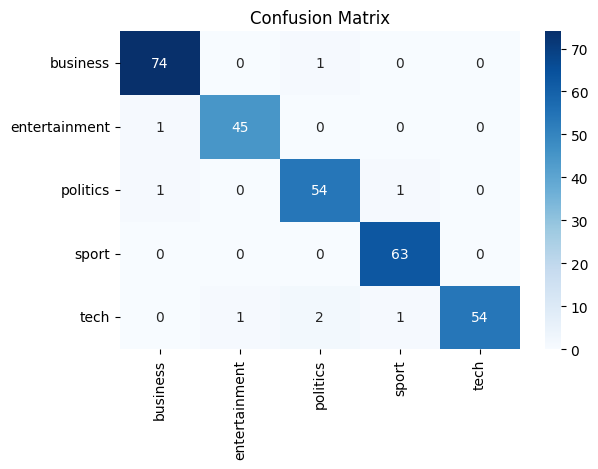

Classifier ready


In [40]:
class Classifier:
    def __init__(self):
        self.vectorizer  = TfidfVectorizer(max_features=1000)
        self.nb          = MultinomialNB()
        self.svm         = LinearSVC(random_state=42)
        self.encoder     = LabelEncoder()
        self.best_model  = None

    def train(self, df):
        X = self.vectorizer.fit_transform(df['cleaned'])
        y = self.encoder.fit_transform(df['category'])
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        self.nb.fit(X_train, y_train)
        self.svm.fit(X_train, y_train)

        nb_acc  = accuracy_score(y_test, self.nb.predict(X_test))
        svm_acc = accuracy_score(y_test, self.svm.predict(X_test))
        print(f'Naive Bayes: {nb_acc:.4f} | SVM: {svm_acc:.4f}')

        self.best_model = self.svm if svm_acc >= nb_acc else self.nb
        print('Best model:', 'SVM' if svm_acc >= nb_acc else 'Naive Bayes')

        y_pred = self.best_model.predict(X_test)
        print(classification_report(y_test, y_pred, target_names=self.encoder.classes_))

        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d',
                    xticklabels=self.encoder.classes_,
                    yticklabels=self.encoder.classes_, cmap='Blues')
        plt.title('Confusion Matrix')
        plt.tight_layout()
        plt.show()

    def predict(self, text):
        X    = self.vectorizer.transform([clean_text(text)])
        pred = self.best_model.predict(X)[0]
        return self.encoder.inverse_transform([pred])[0]

    def predict_with_confidence(self, text):
        X      = self.vectorizer.transform([clean_text(text)])
        scores = self.best_model.decision_function(X)[0]
        idx    = scores.argmax()
        return {'label': self.encoder.inverse_transform([idx])[0], 'confidence': round(float(scores[idx]), 3)}


clf = Classifier()
clf.train(df)
newsbot.classifier = clf
print('Classifier ready')

## Named Entity Recognition

In [29]:
nlp = spacy.load('en_core_web_sm')

def extract_entities(text):
    doc = nlp(text[:1000])
    return {
        'people': list(set(e.text for e in doc.ents if e.label_ == 'PERSON'))[:5],
        'orgs':   list(set(e.text for e in doc.ents if e.label_ == 'ORG'))[:5],
        'places': list(set(e.text for e in doc.ents if e.label_ == 'GPE'))[:5]
    }

newsbot.entity_mapper = extract_entities

print('NER ready')
print(extract_entities(df['content'].iloc[0]))

NER ready
{'people': ['arthur andersen', 'cynthia cooper'], 'orgs': [], 'places': ['us', 'new york']}


## Semantic Search

In [30]:
search_vectorizer = TfidfVectorizer(max_features=1000)
search_matrix     = search_vectorizer.fit_transform(df['cleaned'])

def search(query, top_k=5):
    q_vec   = search_vectorizer.transform([clean_text(query)])
    scores  = cosine_similarity(q_vec, search_matrix)[0]
    top_idx = scores.argsort()[-top_k:][::-1]
    for i in top_idx:
        print(f'[{df["category"].iloc[i]}] score={round(scores[i],3)} — {df["content"].iloc[i][:100]}...')

newsbot.search_engine = search

print('Search ready')
print()
search('football championship results')

Search ready

[sport] score=0.231 — gb select holmes for double bid kelly holmes has been chosen for both the 800m and 1500m at next mon...
[sport] score=0.192 — kluft impressed by sotherton form olympic heptathlon champion carolina kluft was full of admiration ...
[sport] score=0.183 — anelka  eyes man city departure  striker nicolas anelka reportedly wants to leave manchester city in...
[sport] score=0.174 — uk athletics agrees new kit deal uk athletics has agreed a new deal with adidas to supply great brit...
[sport] score=0.172 — mcilroy aiming for madrid title northern ireland man james mcilroy is confident he can win his first...


## Multilingual Support

In [41]:
LANGUAGES = {'en': 'English', 'de': 'German', 'fr': 'French', 'es': 'Spanish'}

def detect_language(text):
    try:
        code = detect(text)
        return {'code': code, 'language': LANGUAGES.get(code, code)}
    except:
        return {'code': 'unknown', 'language': 'unknown'}

LANG_CODES = {
    'de': 'de-DE',
    'fr': 'fr-FR',
    'es': 'es-ES',
    'it': 'it-IT',
    'pt': 'pt-PT'
}

def translate(text, target='en-GB'):
    try:
        target = LANG_CODES.get(target, target)
        return MyMemoryTranslator(source='en-GB', target=target).translate(text[:500])
    except Exception as e:
        return f'Translation failed: {e}'

newsbot.multilingual = {'detect': detect_language, 'translate': translate}

sample = df['content'].iloc[0][:200]
print('Language:', detect_language(sample))
print()
print('German :', translate(sample, 'de'))
print('French :', translate(sample, 'fr'))
print('Spanish:', translate(sample, 'es'))

Language: {'code': 'en', 'language': 'English'}

German : worldcom ex-boss startet verteidigungsanwälte, die den ehemaligen worldcom-chef bernie ebbers gegen eine reihe von betrugsvorwürfen verteidigen, haben einen whistleblower des unternehmens als ihren ersten zeugen angerufen.  cynthia cooper
French : worldcom ex-boss lance des avocats de la défense défendant l'ancien chef de worldcom bernie ebbers contre une batterie d'accusations de fraude ont appelé un dénonciateur d'entreprise comme leur premier témoin.  cynthia cooper
Spanish: el ex jefe de worldcom lanza abogados defensores que defienden al ex jefe de worldcom bernie ebbers contra una batería de cargos de fraude han llamado a un denunciante de la compañía como su primer testigo.  cynthia cooper


## Topic Modeling

In [25]:
class TopicModel:
    def __init__(self):
        self.vectorizer = TfidfVectorizer(max_features=1000)
        self.lda = LatentDirichletAllocation(n_components=config.N_TOPICS)

    def train(self, df):
        X = self.vectorizer.fit_transform(df['cleaned'])
        self.lda.fit(X)

    def get_topics(self, text):
        text = clean_text(text)
        X = self.vectorizer.transform([text])
        return self.lda.transform(X)[0].tolist()

tm = TopicModel()
tm.train(df)
newsbot.topic = tm

## Summarization

In [26]:
class Summarizer:
    def summarize(self, text):
        parser = PlaintextParser.from_string(text, Tokenizer("english"))
        summarizer = LsaSummarizer()
        summary = summarizer(parser.document, 3)
        return " ".join([str(sentence) for sentence in summary])

newsbot.summarizer = Summarizer()

## ChatBot

In [42]:
def chat(query):
    q = query.lower()

    # detect category if mentioned
    category = None
    for cat in ['business', 'entertainment', 'politics', 'sport', 'tech']:
        if cat in q:
            category = cat

    pool = df[df['category'] == category] if category else df

    if 'help' in q:
        return 'Try: summarize, sentiment, topics, entities, classify, translate, or search'

    elif 'summarize' in q or 'summary' in q:
        return newsbot.summarizer.summarize(pool['content'].iloc[0])

    elif 'sentiment' in q or 'tone' in q:
        scores = pool['content'].apply(lambda t: sia.polarity_scores(t)['compound'])
        avg    = round(scores.mean(), 3)
        label  = 'positive' if avg > 0.05 else ('negative' if avg < -0.05 else 'neutral')
        return f'{category or "All"} articles: {label} (avg score: {avg})'

    elif 'topic' in q:
        X      = newsbot.topic.vectorizer.transform(pool['cleaned'].head(50))
        topics = newsbot.topic.lda.transform(X).argmax(axis=1)
        common = Counter(topics).most_common(3)
        return '\n'.join([f'Topic {t}: {c} articles' for t, c in common])

    elif 'entit' in q or 'who' in q or 'company' in q or 'place' in q:
        return str(extract_entities(pool['content'].iloc[0]))

    elif 'classify' in q or 'category' in q:
        return str(newsbot.classifier.predict_with_confidence(pool['content'].iloc[0]))

    elif 'german' in q:
        return translate(pool['content'].iloc[0][:300], 'de')

    elif 'french' in q:
        return translate(pool['content'].iloc[0][:300], 'fr')

    elif 'spanish' in q:
        return translate(pool['content'].iloc[0][:300], 'es')

    else:
        search(query)
        return ''


print('Chatbot ready')
print()
for q in ['help', 'summarize sport', 'sentiment of politics', 'topics in tech', 'who is in business news', 'translate to German']:
    print(f'User: {q}')
    print(f'Bot : {chat(q)}')
    print()

Chatbot ready

User: help
Bot : Try: summarize, sentiment, topics, entities, classify, translate, or search

User: summarize sport
Bot : matt williams  side has shown little in attack  but johnson insisted the scots will be difficult opposition to break down. italy are really brave opposition and sometimes it s very hard to win   he said. scotland are a hard side and very underrated so we re not taking anything for granted.

User: sentiment of politics
Bot : politics articles: positive (avg score: 0.058)

User: topics in tech
Bot : Topic 0: 45 articles
Topic 1: 5 articles

User: who is in business news
Bot : {'people': ['arthur andersen', 'cynthia cooper'], 'orgs': [], 'places': ['us', 'new york']}

User: translate to German
Bot : worldcom ex-boss startet verteidigungsanwälte, die den ehemaligen worldcom chef bernie ebbers gegen eine reihe von betrugsvorwürfen verteidigen, haben einen unternehmens-whistleblower als ihren ersten zeugen angerufen. cynthia cooper worldcom s ex-leiter der 

## Test the system

In [34]:
sample = df['content'].iloc[0]

result = newsbot.analyze(sample)
text = "Apple released a new product and the market reacted positively."

print(newsbot.analyze(text))

print(result)

{'category': 'business', 'sentiment': {'label': 'positive', 'score': 0.5267}, 'topics': [0.7440795390633389, 0.06492377084009684, 0.06366118366395032, 0.06377428322334554, 0.06356122320926837], 'summary': 'Apple released a new product and the market reacted positively.', 'language': 'en'}
{'category': 'business', 'sentiment': {'label': 'negative', 'score': -0.9701}, 'topics': [0.02713669507557244, 0.8826721714772988, 0.02700138563467703, 0.036787110804302005, 0.02640263700814963], 'summary': 'mr ebber s lawyers have said he was unaware of the fraud  arguing that auditors did not alert him to any problems. ms cooper also said that during shareholder meetings mr ebbers often passed over technical questions to the company s finance chief  giving only  brief  answers himself. however  ms cooper said mr sullivan had not mentioned  anything uncomfortable  about worldcom s accounting during a 2001 audit committee meeting.', 'language': 'en'}
